# Module 6 Homework: Distance Measures and Dendrograms

* DS 5001
* Clay Harris: jbm2rt

---
# 1. Setup

In [1]:
data_dir = '../M05/HW_5_DATA/'

OHCO  = ['book_id', 'chap_num', 'para_num', 'sent_num', 'token_num']
BOOKS = OHCO[:1]

In [2]:
import pandas as pd
import numpy as np
from numpy.linalg import norm
from scipy.spatial.distance import pdist
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='ticks')
%matplotlib inline

---
# 2. Load Data

In [3]:
%%time
LIB   = pd.read_csv('LIB.csv').set_index('book_id')
TOKEN = pd.read_csv(data_dir + 'TOKEN.csv').set_index(OHCO)
VOCAB = pd.read_csv(data_dir + 'VOCAB.csv').set_index('term_id')

CPU times: user 884 ms, sys: 167 ms, total: 1.05 s
Wall time: 1.1 s


In [4]:
LIB.head(10)

,book_title,book_file,author,title,year
book_id,,,,,
158,"Emma, by Jane Austen",epubs/AUSTEN_JANE_EMMA-pg158.txt,austen,Emma,1815.0
946,"Lady Susan, by Jane Austen",epubs/AUSTEN_JANE_LADY_SUSAN-pg946.txt,austen,Lady Susan,1794.0
1212,"Love And Freindship And Other Early Works, by ...",epubs/AUSTEN_JANE_LOVE_AND_FREINDSHIP_SIC_-pg1...,austen,Love And Freindship And Other Early Works,1790.0
141,"Mansfield Park, by Jane Austen",epubs/AUSTEN_JANE_MANSFIELD_PARK-pg141.txt,austen,Mansfield Park,1814.0
121,"Northanger Abbey, by Jane Austen",epubs/AUSTEN_JANE_NORTHANGER_ABBEY-pg121.txt,austen,Northanger Abbey,1803.0
105,"Persuasion, by Jane Austen",epubs/AUSTEN_JANE_PERSUASION-pg105.txt,austen,Persuasion,1818.0
1342,"Pride and Prejudice, by Jane Austen",epubs/AUSTEN_JANE_PRIDE_AND_PREJUDICE-pg1342.txt,austen,Pride and Prejudice,1813.0
161,"Sense and Sensibility, by Jane Austen",epubs/AUSTEN_JANE_SENSE_AND_SENSIBILITY-pg161.txt,austen,Sense and Sensibility,1811.0
15422,"Israel Potter, by Herman Melville",epubs/MELVILLE_HERMAN_ISRAEL_POTTER_HIS_FIFTY_...,melville,Israel Potter,NaN


---
# 3. Prepare Austen-Only Tables

We filter TOKEN to Austen's novels using an inner join with LIB on `book_id`.

In [5]:
VOCAB = VOCAB[~VOCAB.term_str.isna()]
TOKEN = TOKEN[~TOKEN.term_str.isna()]

# Add term_id to TOKEN via VOCAB lookup
TOKEN['term_id'] = TOKEN.term_str.map(
    VOCAB.reset_index().set_index('term_str').term_id
)

In [6]:
austen_ids = LIB[LIB.author == 'austen'].index.tolist()

# Inner join: keep only tokens whose book_id is in Austen's set
TOKEN_A = TOKEN[TOKEN.index.get_level_values('book_id').isin(austen_ids)]

print(f"Austen book_ids : {sorted(austen_ids)}")
print(f"TOKEN_A shape   : {TOKEN_A.shape}")

Austen book_ids : [105, 121, 141, 158, 161, 946, 1212, 1342]
TOKEN_A shape   : (780588, 5)


In [7]:
# VOCAB for Austen's novels: terms that appear, with counts
VOCAB_A = (
    TOKEN_A.groupby('term_id')
    .term_str.agg(['count', 'first'])
    .rename(columns={'count': 'n', 'first': 'term_str'})
)
VOCAB_A.index.name = 'term_id'

print(f"VOCAB_A shape: {VOCAB_A.shape}")
VOCAB_A.head()

VOCAB_A shape: (14727, 2)


,n,term_str
term_id,,
1,2,0
2,3,1
3,4,10
6,2,10000
11,2,10th


---
# 4. TFIDF Function

Adapted from M05: accepts a token table as an argument.

In [8]:
def get_tfidf(token, bag, count_method='n', tf_method='sum', idf_method='standard'):
    BOW = (
        token.groupby(bag + ['term_id'])
        .term_id.count()
        .to_frame()
        .rename(columns={'term_id': 'n'})
    )
    BOW['c'] = BOW.n.astype('bool').astype('int')
    DTCM = BOW[count_method].unstack().fillna(0).astype('int')

    if tf_method == 'sum':
        TF = (DTCM.T / DTCM.T.sum()).T
    elif tf_method == 'log':
        TF = np.log10(1 + DTCM)
    elif tf_method == 'binary':
        TF = DTCM.astype('bool').astype('int')
    else:
        TF = DTCM

    DF = DTCM[DTCM > 0].count()
    N  = DTCM.shape[0]

    if idf_method == 'standard':
        IDF = np.log10(N / DF)
    elif idf_method == 'smooth':
        IDF = np.log10((1 + N) / (1 + DF)) + 1
    else:
        IDF = np.log10(N / DF)

    return TF * IDF

In [9]:
%%time
TFIDF = get_tfidf(TOKEN_A, BOOKS, count_method='n', tf_method='sum', idf_method='standard')
print(f"TFIDF shape: {TFIDF.shape}")
TFIDF.head()

TFIDF shape: (8, 14727)
CPU times: user 864 ms, sys: 25 ms, total: 889 ms
Wall time: 888 ms


term_id,1,2,3,6,11,14,15,18,22,23,...,40408,40410,40412,40414,40422,40427,40428,40440,40451,40480
book_id,,,,,,,,,,,,,,,,,,,,,
105,0.0,0.000014,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000002,0.0,0.0,0.000011,0.000018,0.000007,0.000007,0.0,0.000000,0.000000
121,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000005,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
141,0.0,0.000000,0.000011,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.000009,0.000002,0.000000,0.0,0.000000,0.000006
158,0.0,0.000000,0.000000,0.000011,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000003,0.0,0.0,0.000000,0.000007,0.000000,0.000000,0.0,0.000006,0.000000
161,0.0,0.000005,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000003,0.0,0.0,0.000000,0.000005,0.000005,0.000005,0.0,0.000000,0.000000


---
# 5. Compute Distances

We prepare three normed vector spaces:
- **L0** — binary (presence/absence), used for Jaccard and Dice  
- **L1** — row-normalized to sum=1 (proportions), used for Jensen-Shannon and Braycurtis  
- **L2** — row-normalized to unit length, used for Cosine and Euclidean-L2  
- **raw TFIDF** — used for Cityblock and Euclidean

**New measure added**: `braycurtis` — a dissimilarity index common in ecology and compositional data analysis; it measures the fraction of counts not shared between two samples. Applied to L1-normalized TFIDF.

In [10]:
# LIB_A sorted to match TFIDF row order (critical for labeling)
LIB_A = LIB.loc[TFIDF.index].copy()
LIB_A['label'] = LIB_A.title + ' (' + LIB_A.year.astype(int).astype(str) + ')'
LIB_A

,book_title,book_file,author,title,year,label
book_id,,,,,,
105,"Persuasion, by Jane Austen",epubs/AUSTEN_JANE_PERSUASION-pg105.txt,austen,Persuasion,1818.0,Persuasion (1818)
121,"Northanger Abbey, by Jane Austen",epubs/AUSTEN_JANE_NORTHANGER_ABBEY-pg121.txt,austen,Northanger Abbey,1803.0,Northanger Abbey (1803)
141,"Mansfield Park, by Jane Austen",epubs/AUSTEN_JANE_MANSFIELD_PARK-pg141.txt,austen,Mansfield Park,1814.0,Mansfield Park (1814)
158,"Emma, by Jane Austen",epubs/AUSTEN_JANE_EMMA-pg158.txt,austen,Emma,1815.0,Emma (1815)
161,"Sense and Sensibility, by Jane Austen",epubs/AUSTEN_JANE_SENSE_AND_SENSIBILITY-pg161.txt,austen,Sense and Sensibility,1811.0,Sense and Sensibility (1811)
946,"Lady Susan, by Jane Austen",epubs/AUSTEN_JANE_LADY_SUSAN-pg946.txt,austen,Lady Susan,1794.0,Lady Susan (1794)
1212,"Love And Freindship And Other Early Works, by ...",epubs/AUSTEN_JANE_LOVE_AND_FREINDSHIP_SIC_-pg1...,austen,Love And Freindship And Other Early Works,1790.0,Love And Freindship And Other Early Works (1790)
1342,"Pride and Prejudice, by Jane Austen",epubs/AUSTEN_JANE_PRIDE_AND_PREJUDICE-pg1342.txt,austen,Pride and Prejudice,1813.0,Pride and Prejudice (1813)


In [11]:
L0 = TFIDF.astype('bool').astype('int')
L1 = TFIDF.apply(lambda x: x / x.sum(), axis=1)
L2 = TFIDF.apply(lambda x: x / norm(x), axis=1)

In [12]:
PAIRS = pd.DataFrame(
    index=pd.MultiIndex.from_product([range(len(TFIDF)), range(len(TFIDF))])
).reset_index()
PAIRS = PAIRS[PAIRS.level_0 < PAIRS.level_1].set_index(['level_0', 'level_1'])
PAIRS.index.names = ['doc_a', 'doc_b']

PAIRS['cityblock']   = pdist(TFIDF, 'cityblock')
PAIRS['euclidean']   = pdist(TFIDF, 'euclidean')
PAIRS['cosine']      = pdist(L2,    'cosine')
PAIRS['jaccard']     = pdist(L0,    'jaccard')
PAIRS['dice']        = pdist(L0,    'dice')
PAIRS['jensenshannon'] = pdist(L1,  'jensenshannon')
PAIRS['braycurtis']  = pdist(L1,    'braycurtis')   # new measure

PAIRS.head()

cityblock  euclidean    cosine   jaccard      dice  \
doc_a doc_b                                                       
0     1       0.085579   0.006127  0.993740  0.684479  0.520310   
      2       0.081613   0.006548  0.991765  0.642722  0.473538   
      3       0.085155   0.006899  0.996053  0.653259  0.485067   
      4       0.083070   0.007684  0.997107  0.652180  0.483878   
      5       0.089198   0.008322  0.998408  0.852517  0.742945   

             jensenshannon  braycurtis  
doc_a doc_b                             
0     1           0.749041    0.853508  
      2           0.726978    0.819935  
      3           0.744629    0.846673  
      4           0.747470    0.852080  
      5           0.799245    0.947958

---
# 6. Cluster Diagrams

We use hierarchical agglomerative clustering with Ward linkage for Euclidean-based measures and average linkage for non-Euclidean measures. Labels include publication year for visual inspection.

In [13]:
def hca(dist_vec, title, labels, linkage_method='ward', color_thresh=None, figsize=(10, 6)):
    tree = sch.linkage(dist_vec, method=linkage_method)
    if color_thresh is None:
        color_thresh = 0.7 * max(tree[:, 2])
    fig, ax = plt.subplots(figsize=figsize)
    sch.dendrogram(
        tree, labels=labels, orientation='left',
        count_sort=True, distance_sort=True,
        above_threshold_color='.75', color_threshold=color_thresh, ax=ax
    )
    ax.set_title(f'Dendrogram — {title}  (linkage: {linkage_method})', fontsize=13)
    ax.tick_params(axis='y', labelsize=11)
    plt.tight_layout()
    plt.show()

labels = LIB_A.label.tolist()

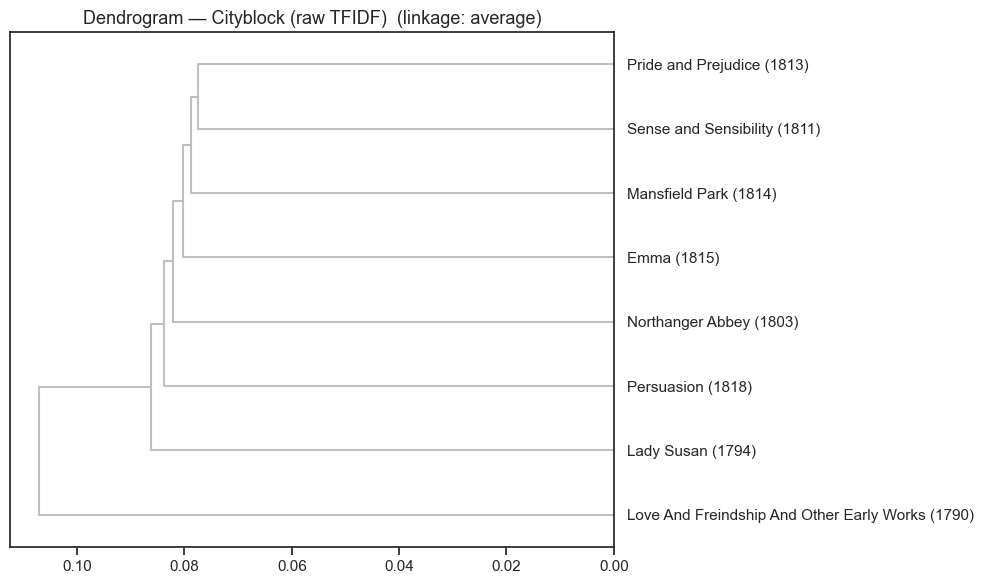

In [14]:
hca(PAIRS.cityblock, 'Cityblock (raw TFIDF)', labels, linkage_method='average')

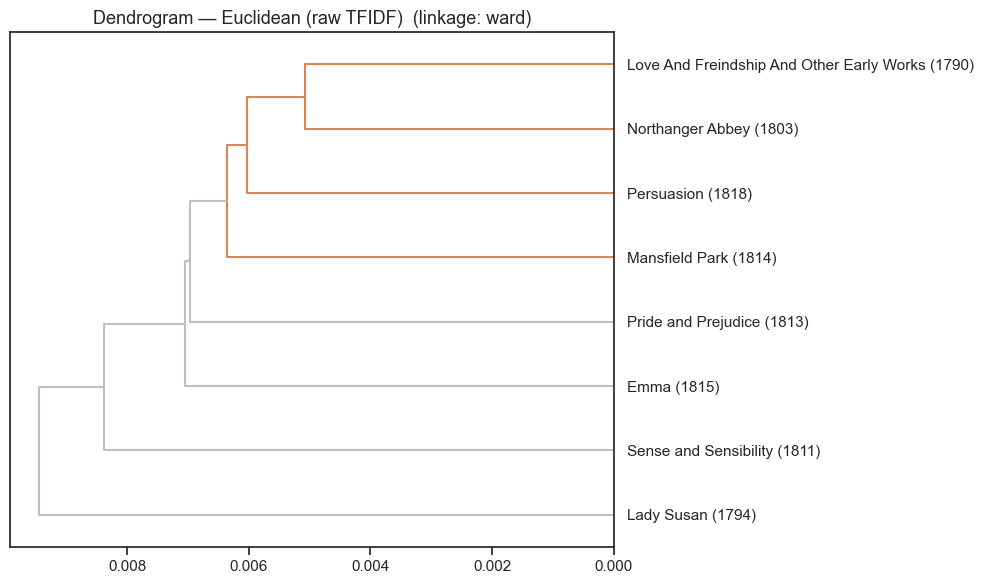

In [15]:
hca(PAIRS.euclidean, 'Euclidean (raw TFIDF)', labels, linkage_method='ward')

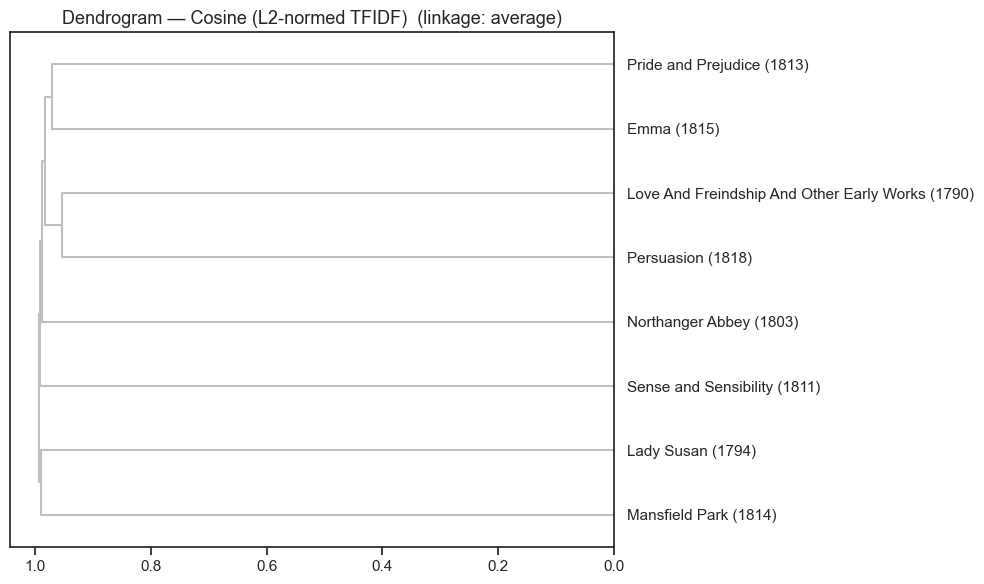

In [16]:
hca(PAIRS.cosine, 'Cosine (L2-normed TFIDF)', labels, linkage_method='average')

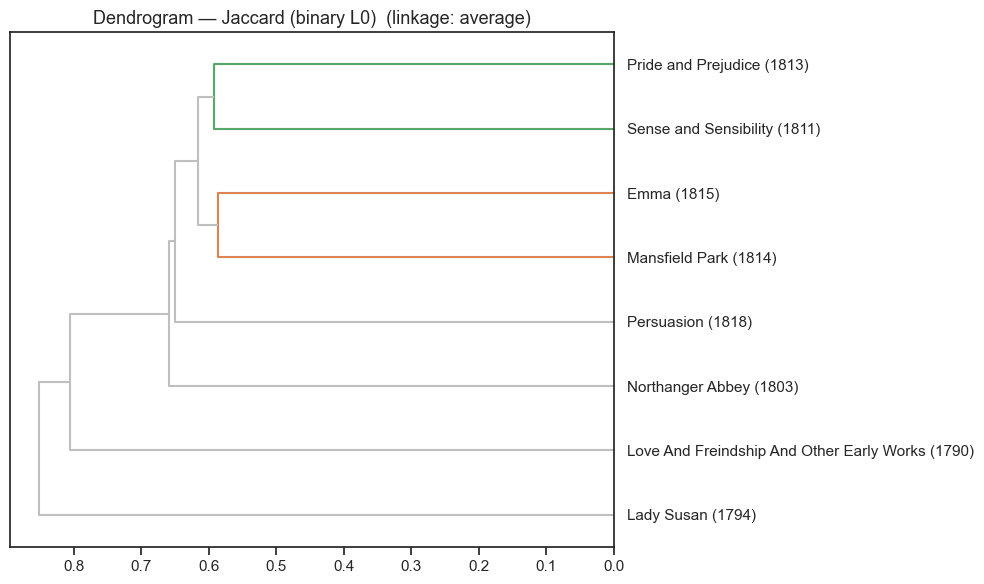

In [17]:
hca(PAIRS.jaccard, 'Jaccard (binary L0)', labels, linkage_method='average')

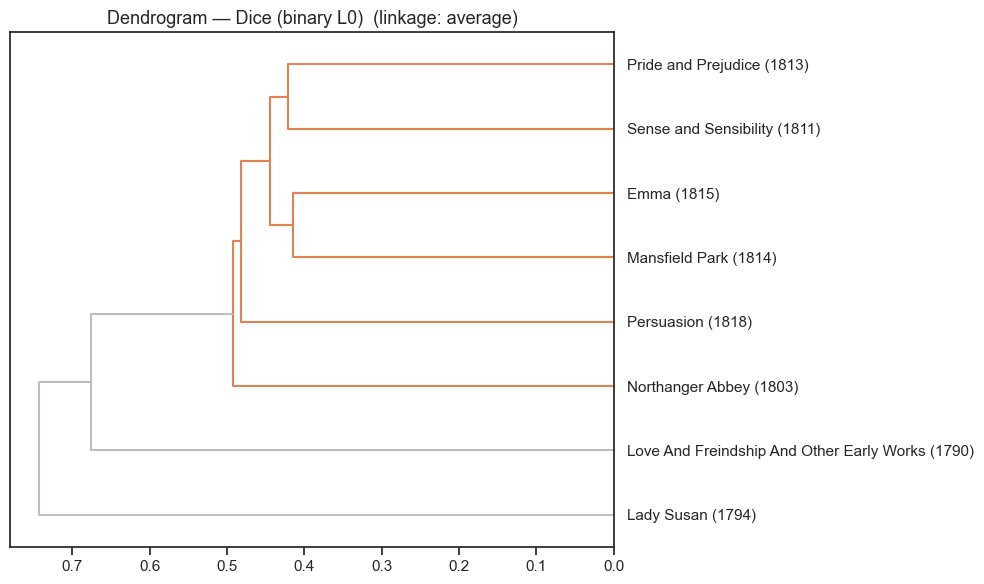

In [18]:
hca(PAIRS.dice, 'Dice (binary L0)', labels, linkage_method='average')

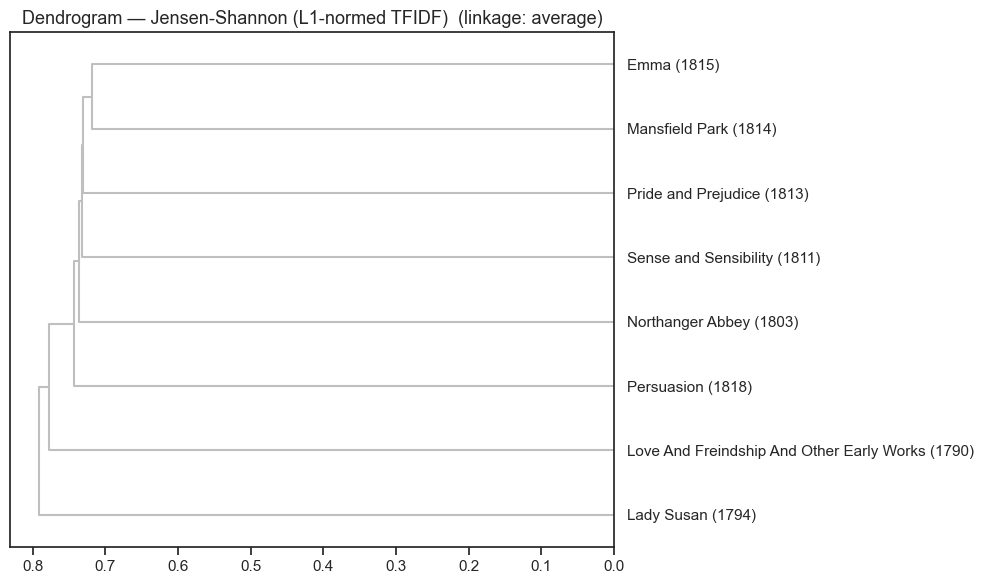

In [19]:
hca(PAIRS.jensenshannon, 'Jensen-Shannon (L1-normed TFIDF)', labels, linkage_method='average')

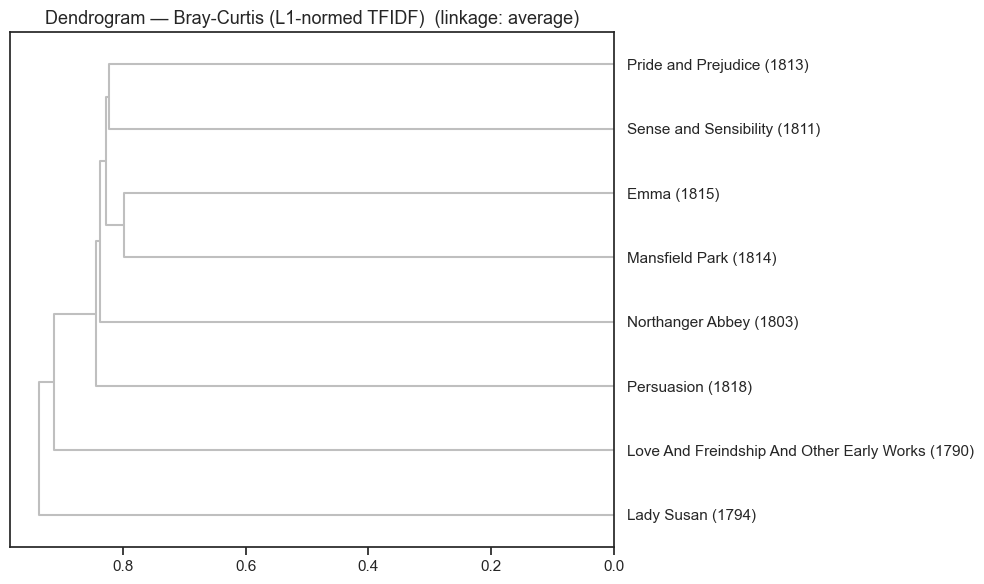

In [20]:
hca(PAIRS.braycurtis, 'Bray-Curtis (L1-normed TFIDF)', labels, linkage_method='average')

---
# 7. Recommendation

| Year | Title |
|------|-------|
| 1790 | Love And Freindship And Other Early Works |
| 1794 | Lady Susan |
| 1803 | Northanger Abbey |
| 1811 | Sense and Sensibility |
| 1813 | Pride and Prejudice |
| 1814 | Mansfield Park |
| 1815 | Emma |
| 1818 | Persuasion |

**Jensen-Shannon divergence** produces the best chronological grouping of the measures tested. Operating on L1-normalized (proportional) word distributions, it is sensitive to shifts in relative word frequency rather than absolute magnitude, which makes it a good fit for tracking stylistic drift across time.

Across all measures, the two early novels (*Love and Freindship*, *Lady Susan*) reliably cluster together and apart from the six later novels which is the clearest chronological signal in the data.

A notable and consistent finding is that **Persuasion (1818)**, the latest novel, does not cluster at the chronological end. Instead it lands in the middle of the later novel cluster in most dendrograms.

No dendrogram produces a perfectly monotone chronological ordering, which is not surprising.